In [1]:
import pandas as pd
import numpy as np
!pip install openpyxl
import seaborn as sns
import matplotlib.pyplot as plt

# Cleaning Data

In [6]:
xl = pd.ExcelFile(r"C:\Users\Khuong Nguyen\Desktop\NurseGPT Eval\Automation Script\observational_Baseline_Data_NoteID_KN_FirstObservation.xlsx")
print(xl.sheet_names)
df_baseline = pd.read_excel(r"C:\Users\Khuong Nguyen\Desktop\NurseGPT Eval\Automation Script\observational_Baseline_Data_NoteID_KN_FirstObservation.xlsx", sheet_name='Benchmarking', header=0)
pd.set_option('display.max_rows', None)
df_baseline= df_baseline.drop(columns = [151, 'Unnamed: 18', 'Total # of Progress Notes ','Notes '])

#Only take KN's data for analysis:
df_baseline['Entry #'] = df_baseline['Entry #'].ffill()
df_baseline = df_baseline[df_baseline["Entry #"] >=10]
#Remove Example Entry
df_baseline = df_baseline[df_baseline['Entry #'] != 100].reset_index(drop=True)
df_baseline = df_baseline.iloc[:143]
df_baseline.columns = df_baseline.columns.str.strip()

['Consent Form', 'Formulas', 'Benchmarking', 'Sheet1']


In [7]:
df_baseline

,Entry #,Date,Nurse ID #,RN or LPN?,"FT, PT, or C?",Time Block,Progress Note #,Progress Note ID #,Progress Note Start Time,Start time,End Time,Time per Charting Moment,Total Time per Progress Note,Progress Note End Time,# of Progress Notes Per Time Block
0,10.0,2026-04-21,13,LPN,FT,10:15AM- 11:45AM,1,49,10:23:00,10:23:00,10:26:00,00:03:00,00:03:00,10:26:00,6.0
1,10.0,NaT,NaN,NaN,NaN,NaN,2,50,10:30:00,10:30:00,10:33:00,00:03:00,00:03:00,10:33:00,NaN
2,10.0,NaT,NaN,NaN,NaN,NaN,3,51,10:37:00,10:37:00,10:41:00,00:04:00,00:04:00,10:41:00,NaN
3,10.0,NaT,NaN,NaN,NaN,NaN,4,52,10:46:00,10:46:00,10:48:00,00:02:00,00:02:00,10:48:00,NaN
4,10.0,NaT,NaN,NaN,NaN,NaN,5,53,11:12:00,11:12:00,11:13:00,00:01:00,00:04:00,11:18:00,NaN
5,10.0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11:15:00,11:18:00,00:03:00,NaN,NaN,NaN
6,10.0,NaT,NaN,NaN,NaN,NaN,6,54,11:44:00,11:44:00,11:45:00,00:01:00,00:01:00,11:45:00,NaN
7,11.0,2026-04-21,11,LPN,PT,2:00PM-3:15PM,1,55,02:04:00,02:04:00,02:05:00,00:01:00,00:01:00,02:05:00,7.0
8,11.0,NaT,NaN,NaN,NaN,NaN,2,56,02:08:00,02:08:00,02:09:00,00:01:00,00:02:00,02:11:00,NaN
9,11.0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02:10:00,02:11:00,00:01:00,NaN,NaN,NaN


In [8]:
#Strip White Space:
df_baseline['RN or LPN?'] = df_baseline['RN or LPN?'].str.strip()
df_baseline['FT, PT, or C?'] = df_baseline['FT, PT, or C?'].str.strip()

#Forward Fills Identifier Columns
col_to_fill = ['Date', 'Nurse ID #', 'Time Block']
df_baseline[col_to_fill] = df_baseline[col_to_fill].ffill()
#Forward fills Nurses Types + Shift only when the total charting time also occurs
condition = df_baseline["Total Time per Progress Note"].notnull()
nurse_shift_fill = ['RN or LPN?', 'FT, PT, or C?']
df_baseline[nurse_shift_fill] = df_baseline[nurse_shift_fill].ffill().where(condition)

# Covert Date Time columns to String Format for SPSS
df_baseline['Date'] = pd.to_datetime(df_baseline['Date'], dayfirst=True).dt.strftime('%d-%m-%Y')

In [9]:
df_baseline

,Entry #,Date,Nurse ID #,RN or LPN?,"FT, PT, or C?",Time Block,Progress Note #,Progress Note ID #,Progress Note Start Time,Start time,End Time,Time per Charting Moment,Total Time per Progress Note,Progress Note End Time,# of Progress Notes Per Time Block
0,10.0,21-04-2026,13,LPN,FT,10:15AM- 11:45AM,1,49,10:23:00,10:23:00,10:26:00,00:03:00,00:03:00,10:26:00,6.0
1,10.0,21-04-2026,13,LPN,FT,10:15AM- 11:45AM,2,50,10:30:00,10:30:00,10:33:00,00:03:00,00:03:00,10:33:00,NaN
2,10.0,21-04-2026,13,LPN,FT,10:15AM- 11:45AM,3,51,10:37:00,10:37:00,10:41:00,00:04:00,00:04:00,10:41:00,NaN
3,10.0,21-04-2026,13,LPN,FT,10:15AM- 11:45AM,4,52,10:46:00,10:46:00,10:48:00,00:02:00,00:02:00,10:48:00,NaN
4,10.0,21-04-2026,13,LPN,FT,10:15AM- 11:45AM,5,53,11:12:00,11:12:00,11:13:00,00:01:00,00:04:00,11:18:00,NaN
5,10.0,21-04-2026,13,NaN,NaN,10:15AM- 11:45AM,NaN,NaN,NaN,11:15:00,11:18:00,00:03:00,NaN,NaN,NaN
6,10.0,21-04-2026,13,LPN,FT,10:15AM- 11:45AM,6,54,11:44:00,11:44:00,11:45:00,00:01:00,00:01:00,11:45:00,NaN
7,11.0,21-04-2026,11,LPN,PT,2:00PM-3:15PM,1,55,02:04:00,02:04:00,02:05:00,00:01:00,00:01:00,02:05:00,7.0
8,11.0,21-04-2026,11,LPN,PT,2:00PM-3:15PM,2,56,02:08:00,02:08:00,02:09:00,00:01:00,00:02:00,02:11:00,NaN
9,11.0,21-04-2026,11,NaN,NaN,2:00PM-3:15PM,NaN,NaN,NaN,02:10:00,02:11:00,00:01:00,NaN,NaN,NaN


In [10]:
# Export to new Excel Files
df_baseline.to_csv("KN_Baseline_Observational_Data_SPSS_Analysis", index = False)

# Remove Outliers in Total Charting Time per Notes columns After March 26th,2026 Meeting

In [6]:
df_baseline_copy = df_baseline.copy() #Create copy of original DF for outliers removal
df_baseline_copy.dtypes

Date                                      str
Nurse ID #                            float64
RN or LPN?                                str
FT, PT, or C?                             str
Time Block                                str
Progress Note #                       float64
Progress Note ID #                    float64
Progress Note Start Time               object
Start time                             object
End time                               object
Time per Charting Moment               object
Total Time per Progress Note           object
Progress Note End Time                 object
# of Progress Notes Per Time Block    float64
dtype: object

In [7]:
df_baseline_copy.columns

Index(['Date', 'Nurse ID #', 'RN or LPN?', 'FT, PT, or C?', 'Time Block',
       'Progress Note #', 'Progress Note ID #', 'Progress Note Start Time',
       'Start time', 'End time', 'Time per Charting Moment',
       'Total Time per Progress Note', 'Progress Note End Time',
       '# of Progress Notes Per Time Block'],
      dtype='str')

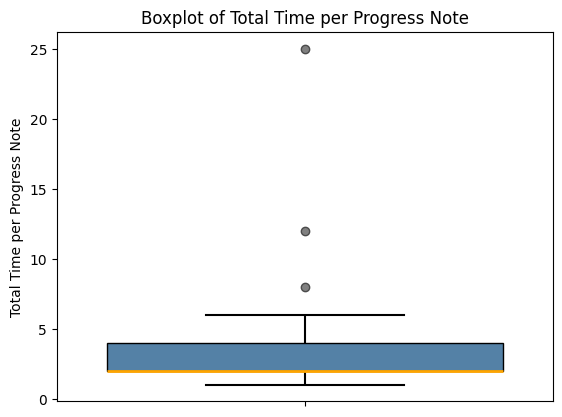

In [8]:
# Function to convert everything date time to integer:
def convert_int_time(col):
    col_seconds = pd.to_timedelta(col.astype(str)).dt.total_seconds()
    col_minute = col_seconds / 60
    return col_minute

col_to_apply = ['Total Time per Progress Note']
df_baseline_copy[col_to_apply] = df_baseline_copy[col_to_apply].apply(convert_int_time)

#Plot to visualize the outliers before removal
plt.style.use('default')
fig, ax = plt.subplots(facecolor='white')
sns.boxplot(df_baseline_copy['Total Time per Progress Note'],
            color = 'steelblue',
            medianprops = dict(color='orange', linewidth=2),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            boxprops=dict(edgecolor='black'),
            flierprops=dict(markerfacecolor='gray', marker='o'),
            ax=ax)
ax.set_facecolor('white')
ax.set_title('Boxplot of Total Time per Progress Note')
plt.show()

In [9]:
df_baseline_copy.shape

(65, 14)

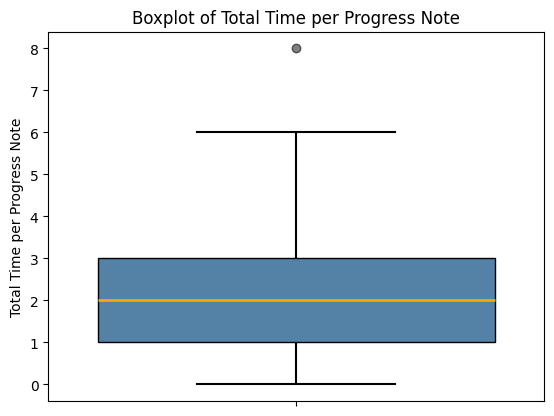

In [16]:
#Fill null values as 0
df_baseline_copy = df_baseline_copy.fillna(0)
# Remove 25 minutes mark and visualize distribution:
def remove_outliers(df, col):
    threshold = 10
    removed_outliers = df[df[col] <= threshold]
    return removed_outliers

df_baseline_copy_no_outliers = remove_outliers(df_baseline_copy, 'Total Time per Progress Note')
df_baseline_copy_no_outliers['Total Time per Progress Note'].unique()

#Plot to visualize the outliers before removal
plt.style.use('default')
fig, ax = plt.subplots(facecolor='white')
sns.boxplot(df_baseline_copy_no_outliers['Total Time per Progress Note'],
            color = 'steelblue',
            medianprops = dict(color='orange', linewidth=2),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            boxprops=dict(edgecolor='black'),
            flierprops=dict(markerfacecolor='gray', marker='o'),
            ax=ax)
ax.set_facecolor('white')
ax.set_title('Boxplot of Total Time per Progress Note')
plt.show()

#Export DataFrame for Analysis without 25 minute outlier:
df_baseline_copy_no_outliers.to_csv("baseline_clean_data_ffill_NurseShift_Types_Outliers_Removed", index = False)

In [17]:
df_baseline_copy_no_outliers.shape

(63, 14)

In [18]:
df_baseline_copy.shape

(65, 14)

In [13]:
df_baseline_copy_no_outliers

,Date,Nurse ID #,RN or LPN?,"FT, PT, or C?",Time Block,Progress Note #,Progress Note ID #,Progress Note Start Time,Start time,End time,Time per Charting Moment,Total Time per Progress Note,Progress Note End Time,# of Progress Notes Per Time Block
0,21-04-2025,1.0,RN,PT,0930-1230,1.0,1.0,07:14:00,07:14:00,07:16:00,00:02:00,8.0,07:30:00,2.0
1,21-04-2025,1.0,0,0,0930-1230,0.0,0.0,0,07:20:00,07:21:00,00:01:00,0.0,0,0.0
2,21-04-2025,1.0,0,0,0930-1230,0.0,0.0,0,07:25:00,07:30:00,00:05:00,0.0,0,0.0
4,21-04-2025,1.0,0,0,0930-1230,0.0,0.0,0,09:32:00,09:37:00,00:05:00,0.0,0,0.0
5,05-05-2025,5.0,LPN,FT,0930 - 1200,1.0,3.0,10:40:00,10:40:00,10:44:00,00:04:00,4.0,10:44:00,4.0
6,05-05-2025,5.0,LPN,FT,0930 - 1200,2.0,4.0,11:01:00,11:01:00,11:05:00,00:04:00,4.0,11:05:00,0.0
7,05-05-2025,5.0,LPN,FT,0930 - 1200,3.0,5.0,11:13:00,11:13:00,11:15:00,00:02:00,2.0,11:15:00,0.0
8,05-05-2025,5.0,LPN,FT,0930 - 1200,4.0,6.0,11:41:00,11:41:00,11:44:00,,3.0,11:44:00,0.0
9,05-05-2025,5.0,LPN,FT,1:30pm-3:00pm,1.0,7.0,01:52:00,01:52:00,01:55:00,00:03:00,3.0,01:55:00,8.0
10,05-05-2025,5.0,LPN,FT,1:30pm-3:00pm,2.0,8.0,01:58:00,01:58:00,02:02:00,00:04:00,4.0,02:02:00,0.0


In [14]:
df_baseline_copy

,Date,Nurse ID #,RN or LPN?,"FT, PT, or C?",Time Block,Progress Note #,Progress Note ID #,Progress Note Start Time,Start time,End time,Time per Charting Moment,Total Time per Progress Note,Progress Note End Time,# of Progress Notes Per Time Block
0,21-04-2025,1.0,RN,PT,0930-1230,1.0,1.0,07:14:00,07:14:00,07:16:00,00:02:00,8.0,07:30:00,2.0
1,21-04-2025,1.0,0,0,0930-1230,0.0,0.0,0,07:20:00,07:21:00,00:01:00,0.0,0,0.0
2,21-04-2025,1.0,0,0,0930-1230,0.0,0.0,0,07:25:00,07:30:00,00:05:00,0.0,0,0.0
3,21-04-2025,1.0,RN,PT,0930-1230,2.0,2.0,09:23:00,09:23:00,09:30:00,00:07:00,12.0,09:37:00,0.0
4,21-04-2025,1.0,0,0,0930-1230,0.0,0.0,0,09:32:00,09:37:00,00:05:00,0.0,0,0.0
5,05-05-2025,5.0,LPN,FT,0930 - 1200,1.0,3.0,10:40:00,10:40:00,10:44:00,00:04:00,4.0,10:44:00,4.0
6,05-05-2025,5.0,LPN,FT,0930 - 1200,2.0,4.0,11:01:00,11:01:00,11:05:00,00:04:00,4.0,11:05:00,0.0
7,05-05-2025,5.0,LPN,FT,0930 - 1200,3.0,5.0,11:13:00,11:13:00,11:15:00,00:02:00,2.0,11:15:00,0.0
8,05-05-2025,5.0,LPN,FT,0930 - 1200,4.0,6.0,11:41:00,11:41:00,11:44:00,,3.0,11:44:00,0.0
9,05-05-2025,5.0,LPN,FT,1:30pm-3:00pm,1.0,7.0,01:52:00,01:52:00,01:55:00,00:03:00,3.0,01:55:00,8.0
